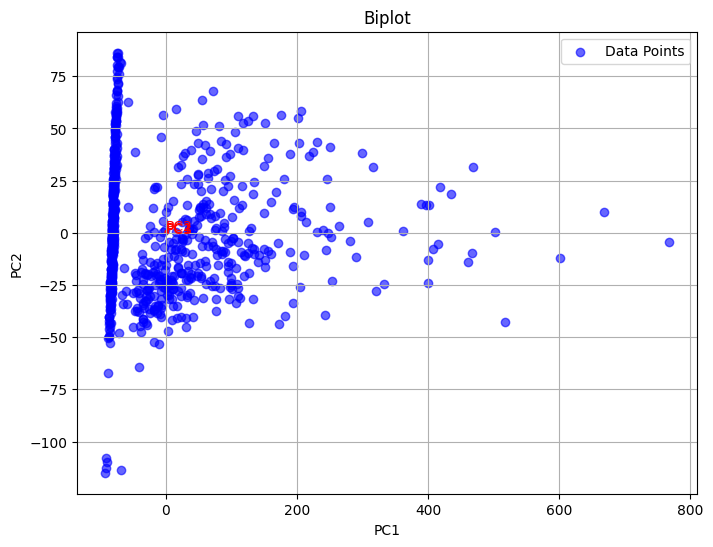

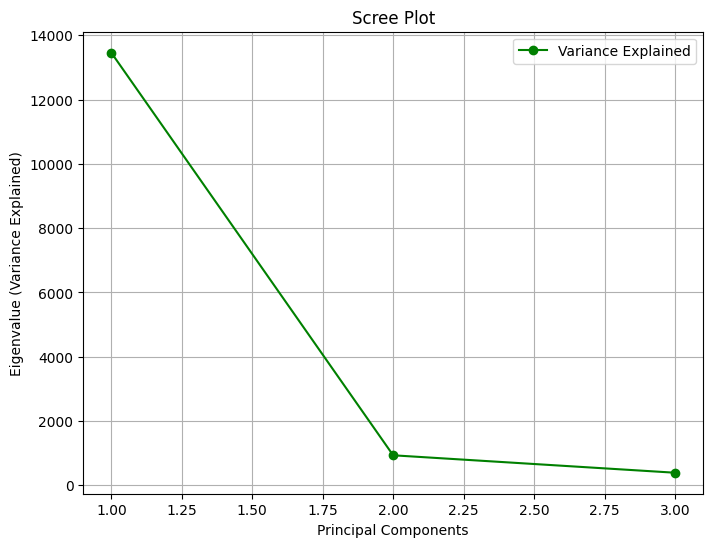

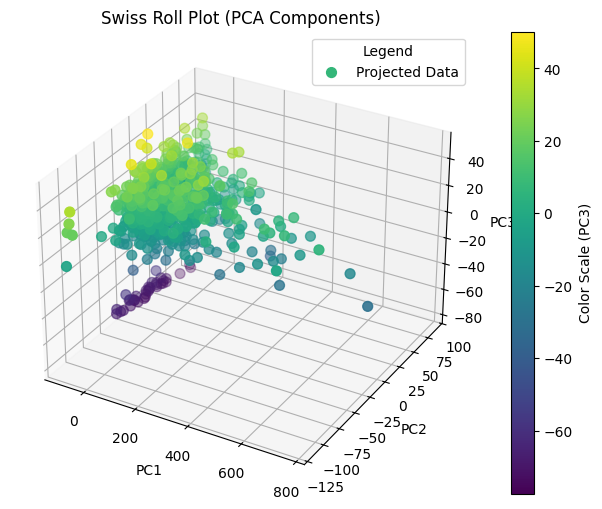

In [17]:
import csv
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Helper functions (from the previous implementation)
def mean(data):
    return sum(data) / len(data)

def subtract_mean(data):
    means = [mean(feature) for feature in zip(*data)]
    return [[x - m for x, m in zip(row, means)] for row in data], means

def dot_product(vec1, vec2):
    return sum(x * y for x, y in zip(vec1, vec2))

def transpose(matrix):
    return list(zip(*matrix))

def covariance_matrix(data):
    data_t = transpose(data)
    n = len(data)
    return [[dot_product(data_t[i], data_t[j]) / (n - 1) for j in range(len(data_t))] for i in range(len(data_t))]

def magnitude(vec):
    return math.sqrt(dot_product(vec, vec))

def normalize(vec):
    mag = magnitude(vec)
    return [x / mag for x in vec]

def eigen_decomposition(matrix, max_iter=100, tol=1e-6):
    n = len(matrix)
    vec = [1] * n
    eigenvalue = 0

    for _ in range(max_iter):
        new_vec = [sum(matrix[i][j] * vec[j] for j in range(n)) for i in range(n)]
        new_eigenvalue = magnitude(new_vec)
        new_vec = normalize(new_vec)

        if abs(new_eigenvalue - eigenvalue) < tol:
            break
        vec = new_vec
        eigenvalue = new_eigenvalue

    return eigenvalue, vec

def pca(data, n_components):
    centered_data, means = subtract_mean(data)
    cov_matrix = covariance_matrix(centered_data)

    eigenvalues = []
    eigenvectors = []

    for _ in range(n_components):
        val, vec = eigen_decomposition(cov_matrix)
        eigenvalues.append(val)
        eigenvectors.append(vec)

        for i in range(len(cov_matrix)):
            for j in range(len(cov_matrix)):
                cov_matrix[i][j] -= val * vec[i] * vec[j]

    eigenvectors = [normalize(vec) for vec in eigenvectors]
    projected_data = [[dot_product(row, vec) for vec in eigenvectors] for row in centered_data]

    return projected_data, eigenvalues, eigenvectors, means

# Load data from CSV
def load_csv(file_path):
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip the header row
        data = [list(map(float, row)) for row in reader]
    return data

# Biplot
def biplot(projected_data, eigenvectors):
    plt.figure(figsize=(8, 6))
    
    # Plot data points
    for i in range(len(projected_data)):
        plt.scatter(projected_data[i][0], projected_data[i][1], color='blue', alpha=0.6, label='Data Points' if i == 0 else "")
    
    # Plot eigenvectors
    for i, vec in enumerate(eigenvectors):
        plt.arrow(0, 0, vec[0], vec[1], color='red', head_width=0.05)
        plt.text(vec[0] * 1.2, vec[1] * 1.2, f"PC{i+1}", color='red')
    
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Biplot')
    plt.legend(loc='upper right')  # Add legend
    plt.grid()
    plt.show()


# Scree plot
def scree_plot(eigenvalues):
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='green', label='Variance Explained')
    plt.xlabel('Principal Components')
    plt.ylabel('Eigenvalue (Variance Explained)')
    plt.title('Scree Plot')
    plt.legend(loc='best')  # Add legend
    plt.grid()
    plt.show()


# Swiss Roll plot (3D)
def swiss_roll_plot(projected_data):
    # Use the first three principal components
    reduced_data = [row[:3] for row in projected_data]
    x, y, z = zip(*reduced_data)
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=50, label='Projected Data')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.title('Swiss Roll Plot (PCA Components)')
    
    # Add legend
    legend = ax.legend(loc='upper right', title="Legend")
    plt.colorbar(scatter, ax=ax, label='Color Scale (PC3)')
    plt.show()



# Main program
if __name__ == "__main__":
    file_path = 'pima-indians-diabetes.csv'  # Replace with your actual file path
    data = load_csv(file_path)

    # Perform PCA
    n_components = 3  # Set the number of components for PCA
    projected_data, eigenvalues, eigenvectors, means = pca(data, n_components)

    # Create the plots
    biplot(projected_data, eigenvectors)  # Biplot for PC1 and PC2
    scree_plot(eigenvalues)              # Scree plot for variance explained
    swiss_roll_plot(projected_data)      # Swiss Roll plot for PC1, PC2, and PC3


In [2]:
import pandas as pd
data = pd.read_csv("pima-indians-diabetes.csv")
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetespedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object